# Pràctica 1: Identificació d'idiomes

Jaume Majó i David Vàzquez

L'objectiu d'aquesta pràctica és implementar un identificador d'idiomes (basat en trigrames de caràcters) de les principals llengües europees: anglès, castellà, neerlandès, alemany, italià i francès. Per fer-ho, ens basarem amb el corpus wortschatz leipzig que conté textos de forma i mida similar en els diferents idiomes esmentats.

## 1. Importem les llibreries
En primer lloc importem les llibreries necessàries per a la implementeció de l'identificador d'idiomes. 

In [42]:
import nltk
import re
import os
from math import log, exp
from nltk.collocations import BigramCollocationFinder, TrigramCollocationFinder, QuadgramCollocationFinder
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.base import BaseEstimator
from sklearn.metrics import make_scorer, accuracy_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd
import random

## 2. Preprocessing
A continuació, creem una funció `preprocessing(file_path)` que donat un `filepath` retorna el text preprocessat d'aquest fitxer. El preprocessament consta dels seguents passos:
- Eliminar els símbols que es troben entre números ja que si no, en llengües com l'alemany, quedaven punts aïllats.
- Eliminar els números.
- Substituir espais múltiples i tabulacions per un únic espai.
- Convertir tot el text a minúscula.
- Concatenar totes les frases amb separació de 2 espais. D'aquesta manera, com que utilitzarem trigrames, ens asegurem que no hi haurà un trigrama amb parts de dues frases diferents.

In [2]:
def preprocessing(file_path):
    with open(file_path, 'r', encoding='utf-8') as file:
        raw_text = file.read()
    cleaned_text = re.sub(r'(\d)[.:](\d)', r'\1\2', raw_text) # Eliminar simbols en mig dels números
    cleaned_text = re.sub(r'\d+', '', cleaned_text)  # Eliminar els números
    cleaned_text = re.sub(r'[ \t]+', ' ', cleaned_text) # Canviar (1 o més)espais i tabulacions per 1 espai
    cleaned_text = cleaned_text.lower()  # Canviar mayúscules a minúscules
    cleaned_text = cleaned_text.replace("\n", "  ") # Canviar salts de linia per espais dobles
    cleaned_text = re.sub(r' {2,}', '  ', cleaned_text) # Canviar (2 o més)espais per 2 espais
    cleaned_text = '  ' + cleaned_text.strip() + '  ' # Posar espais dobles al principi i al final després d'eliminar els espais qu hi hagin amb strip
    return cleaned_text

## 3. Càlcul de probabilitats
Definim les funcions auxiliars per calcular el valor de les probabilitats de cada idioma en el mètode de smoothing de `absolute_discounting`, `linear_discounting` i `lidstone`.

In [ ]:
def absolute_discounting(trad_idioma, res, N, B, delta): # Absolute discounting smoothing method
    N_0 = B - len(set(trad_idioma) & set(res))
    tot = 0
    for k, v in res.items():
        if k in trad_idioma:
            tot += v*log((trad_idioma[k] - delta)/N) if trad_idioma[k] - delta != 0 else 0
        else:
            tot += v*log(((B - N_0)*(delta / N_0))/N) if (B - N_0)*delta != 0 else 0
    return tot

def linear_discounting(trad_idioma, res, N, B, alpha): # Linear discounting smoothing method
    N_0 = B - len(set(trad_idioma) & set(res))
    tot = 0
    for k, v in res.items():
        if k in trad_idioma:
            tot += v*log((1 - alpha)*trad_idioma[k]/N) if (1 - alpha)*trad_idioma[k] != 0 else 0
        else:
            tot += v*log(alpha/N_0) if alpha != 0 else 0
    return tot

def lidstone(trad_idioma, res, N, B, lambd): # Lidstone smoothing method
    tot = 0
    for k, v in res.items():
        tot += v*log((trad_idioma.get(k, 0) + lambd)/(N + lambd*B)) if trad_idioma.get(k, 0) + lambd != 0 else 0
    return tot

## 4. Model identificador d'idiomes

Definim la classe `IdentificadorIdiomas` amb la que entrenarem el model per detectar l'idioma.  

Amb el mètode `fit` podem entrenar el model per emmagatzemar els trigrams dels corpus amb la seva etiqueta d'idioma.  
Amb el mètode `predict` calculem les probabilitats per a cada idioma, segons el mètode de smoothing escollit i retornem l'idioma més probable.

In [ ]:
class IdentificadorIdiomas(BaseEstimator):

    def __init__(self, trigram = dict(), labels = [], B = dict(), N = dict(), method = "lidstone", B_compute = "unified", lambd = 0.5):
        self.trigram = trigram
        self.labels = labels
        self.B = B
        self.N = N
        self.method = method
        self.B_compute = B_compute
        self.lambd = lambd

    def prob_idioma(self, res, trad, method, lambd):
        idiomas = dict()
        if method == "lidstone":
            for k, v in trad.items():
                idiomas[k] = lidstone(v, res, self.N[k], self.B[k], lambd)
        elif method == "linear_discounting":
            for k, v in trad.items():
                idiomas[k] = linear_discounting(v, res, self.N[k], self.B[k], lambd)
        elif method == "absolute_discounting":
            for k, v in trad.items():
                idiomas[k] = absolute_discounting(v, res, self.N[k], self.B[k], lambd)
        return idiomas

    def fit(self, X, y):
        for idx, text in enumerate(X):
            finder = TrigramCollocationFinder.from_words(text)
            self.trigram.setdefault(y[idx], {})
            for k, v in finder.ngram_fd.items():
                self.trigram[y[idx]][k] = self.trigram[y[idx]].get(k, 0) + v
            self.B[y[idx]] = len(self.trigram.get(y[idx], []))
            self.N[y[idx]] = self.N.get(y[idx], 0) + sum(finder.ngram_fd.values())
        if self.B_compute == "unified":
            unique_keys = set()
            for k in self.trigram:
                unique_keys = unique_keys | set(self.trigram[k])
            for k in self.B:
                self.B[k] = len(unique_keys)
        return self

    def predict(self, X, method = None, lambd = None):
        # Pots canviar el metode per calcular les probabilitats
        method = method if method is not None else self.method
        lambd = lambd if lambd is not None else self.lambd
        traductor = dict()
        for k, v in self.trigram.items():
            traductor[k] = self.trigram[k].copy()
            traductor[k] = {key:traductor[k][key] for key in traductor[k] if traductor[k][key] >= 5}
        y_pred = []
        for text in X:
            finder = TrigramCollocationFinder.from_words(text)
            idiomes_pred = self.prob_idioma(finder.ngram_fd, traductor, method, lambd)
            idioma_pred = max(idiomes_pred, key=idiomes_pred.get)
            y_pred.append(idioma_pred)
        self.labels = [k for k in self.trigram]
        return y_pred
    
    def get_params(self, deep=True):
        return {
            "trigram": self.trigram,
            "B": self.B,
            "N": self.N,
            "method": self.method,
            "B_compute": self.B_compute,
            "lambd": self.lambd
        }

    def set_params(self, **params):
        for key, value in params.items():
            setattr(self, key, value)
        return self

## 5. Corpus de training i test
Per cadascun dels idiomes, fem el preprocessament dels documents del conjunt de training. Per poder particionar els corpus de training pel crossvalidation, dividim els textos en strings de 10 frases cadascuna separades per doble espai.  
Guardem els textos a `X_training` i les seves etiquetes en `y_training`.

In [ ]:
directory_path = 'langId'
traductor = dict()
X_training = []
y_training = []

for filename in os.listdir(directory_path):
    file_path = os.path.join(directory_path, filename)

    if os.path.isfile(file_path) and filename.endswith('trn.txt'):
        print(f"Trobat fitxer: {filename}")

        text = preprocessing(file_path) 
        text = text.split('  ') # Separem per doble espais
        text.pop(0) # El primer es un espai, no es una frase
        text.pop() # L'ultim es un espai, no es una frase
        text = [f"  {item}  " for item in text] # Afegim espais (que hem tret al separar amb split) al principi i al final de cada frase
        text = ["".join(text[i : i + 10]) for i in range(0, len(text), 10)] # Juntem cada 10 frases
        text = [re.sub(r' {2,}', '  ', frase) for frase in text] # Canviem cada cuadruple espai por doble espai

        X_training.extend(text)
        y_training.extend([filename[:3]]*len(text))

Found file: deu_trn.txt
Found file: eng_trn.txt
Found file: fra_trn.txt
Found file: ita_trn.txt
Found file: nld_trn.txt
Found file: spa_trn.txt


De la mateixa manera, per cadascun dels idiomes, fem el preprocessament dels documents del conjunt de test. A diferència d'abans, dividirem el text per frases, ja que les prediccions es faran sobre aquestes.  
Guardem els textos a `X_test` i les seves etiquetes en `y_test`.

In [ ]:
directory_path = 'langId'
test_results = dict()
X_test = []
y_test = []

for filename in os.listdir(directory_path):
    file_path = os.path.join(directory_path, filename)

    if os.path.isfile(file_path) and filename.endswith('tst.txt'):
        print(f"Trobat fitxer: {filename}")

        text = preprocessing(file_path)
        text = text.split('  ') # Separem per doble espais
        text.pop(0) # El primer es un espai, no es una frase
        text.pop() # L'ultim es un espai, no es una frase
        text = [f"  {item}  " for item in text] # Afegim espais (que hem tret al separar amb split) al principi i al final de cada frase

        X_test.extend(text)

        y_test.extend([filename[:3]]*len(text))

Found file: deu_tst.txt
Found file: eng_tst.txt
Found file: fra_tst.txt
Found file: ita_tst.txt
Found file: nld_tst.txt
Found file: spa_tst.txt


## 6. Entrenament, predicció i visualització de resultats
Entrenem el model amb els corpus de training i fem una predicció amb el mètode de lidstone.  
Grafiquem la matriu de confusió del nostre identificador d'idioma.  
Obtenim una precisió del 99,87% la qual cosa ens indica que el model funciona correctament ja que, com ja hem vist, els corpus de training i de test utilitzen les mateixes frases i, per tant, la precisió es tant elevada.

In [ ]:
II = IdentificadorIdiomas(method = "absolute_discounting", B_compute="not_unified", lambd = 0.2)
II.fit(X_training, y_training)
II.predict(X_test, method="lidstone", lambd = 0.5)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=II.labels, yticklabels=II.labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

## 7. Crossvalidation per trobar els millors paràmetres
### Lidstone
De la formula de smoothing de lidstone, per trigrams:

$$ P(w_1 w_2 w_3) = \frac{C(w_1 w_2 w_3) + \lambda}{N + \lambda B} $$

Necessitem $C(w_1 w_2 w_3)$ que es el nombre de vegades que surt cert trigram als corpus de training. També fa falta $N$ que es el nombre de trigrams dels corpus de training.  
Però $B$ es el nombre de trigrams únics vistos que podem considerar els trigrams diferents per cada llengüatge o unificar els llengüatges. I $\lambda$ es una constant que evita les probabilitats de zero per a trigrams desconeguts, i volem trobar el seu millor valor.  
Per saber si pel mètode de smoothing lidstone es millor utilitzar una $B$ diferent per cada llengüatge o si es millor unificar-les i, a més, per saber quina $\lambda$ es millor, farem un crossvalidation per trobar el millor model.

Accuracy: 0.9981659636193875


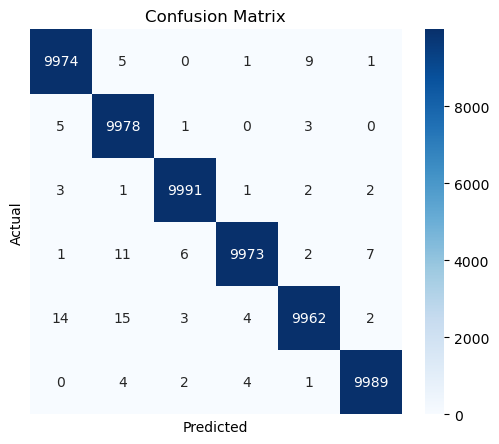

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
unified_0.001,"{'B_compute': 'unified', 'lambd': 0.001}",1,1.000000,0.000000
unified_0.005,"{'B_compute': 'unified', 'lambd': 0.005}",1,1.000000,0.000000
unified_0.01,"{'B_compute': 'unified', 'lambd': 0.01}",1,1.000000,0.000000
unified_0.05,"{'B_compute': 'unified', 'lambd': 0.05}",1,1.000000,0.000000
unified_0.1,"{'B_compute': 'unified', 'lambd': 0.1}",1,1.000000,0.000000
unified_0.5,"{'B_compute': 'unified', 'lambd': 0.5}",1,1.000000,0.000000
unified_1,"{'B_compute': 'unified', 'lambd': 1}",1,1.000000,0.000000
not_unified_0.001,"{'B_compute': 'not_unified', 'lambd': 0.001}",1,1.000000,0.000000
not_unified_0.005,"{'B_compute': 'not_unified', 'lambd': 0.005}",1,1.000000,0.000000


In [38]:
param_grid = {
    "lambd": [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1],
    "B_compute": ["unified", "not_unified"]
}

II = IdentificadorIdiomas(method="lidstone")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    estimator=II,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs.fit(X_training, y_training)

y_pred = gs.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=II.labels, yticklabels=II.labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

Com que l'accuracy es massa alta i està sent arrodonida, farem el cross validation manualment.

In [52]:
my_random = random.Random()
my_random.seed(2)
training_data = list(zip(X_training, y_training))
my_random.shuffle(training_data)
X_training_shuffled, y_training_shuffled = zip(*training_data)
X_partitions = [X_training_shuffled[i:i + len(X_training_shuffled)//5] for i in range(0, len(X_training_shuffled), len(X_training_shuffled)//5)]
y_partitions = [y_training_shuffled[i:i + len(y_training_shuffled)//5] for i in range(0, len(y_training_shuffled), len(y_training_shuffled)//5)]

scores = {"lidstone": {"unified" : {}, "not_unified" : {}}, "linear_discounting": {"unified" : {}, "not_unified" : {}}, "absolute_discounting": {"unified" : {}, "not_unified" : {}}}
for B_compute in ["unified", "not_unified"]:
    for method in ["lidstone", "linear_discounting", "absolute_discounting"]:
        for lambd in [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]:
            scores[method][B_compute][lambd] = []

for B_compute in ["unified", "not_unified"]:
    for i in range(len(X_partitions)):
        II = IdentificadorIdiomas(B_compute=B_compute)
        for j in range(len(X_partitions)):
            if j != i:
                II.fit(X_partitions[j], y_partitions[j])
        for method in ["lidstone", "linear_discounting", "absolute_discounting"]:
            for lambd in [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]:
                y_pred = II.predict(X_partitions[i], method=method, lambd=lambd)
                scores[method][B_compute][lambd].append(accuracy_score(y_partitions[i], y_pred))

for method in scores:
    print("Smoothing method:", method)
    for B_compute in scores[method]:
        for lambd, values in scores[method][B_compute].items():
            if method == "lidstone":
                print(f"B: {B_compute} lambda: {lambd} avg_accuracy: {sum(values)/len(values)}")
            elif method == "linear_discounting":
                print(f"B: {B_compute} alpha: {lambd} avg_accuracy: {sum(values)/len(values)}")
            elif method == "absolute_discounting":
                print(f"B: {B_compute} delta: {lambd} avg_accuracy: {sum(values)/len(values)}")
    print()

KeyboardInterrupt: 

In [53]:
for method in scores:
    print("Smoothing method:", method)
    for B_compute in scores[method]:
        for lambd, values in scores[method][B_compute].items():
            if method == "lidstone":
                print(f"B: {B_compute} lambda: {lambd} avg_accuracy: {sum(values)/len(values)}")
            elif method == "linear_discounting":
                print(f"B: {B_compute} alpha: {lambd} avg_accuracy: {sum(values)/len(values)}")
            elif method == "absolute_discounting":
                print(f"B: {B_compute} delta: {lambd} avg_accuracy: {sum(values)/len(values)}")
    print()

Smoothing method: lidstone
B: unified lambda: 0 avg_accuracy: 0.9505143174867946
B: unified lambda: 0.001 avg_accuracy: 1.0
B: unified lambda: 0.005 avg_accuracy: 1.0
B: unified lambda: 0.01 avg_accuracy: 1.0
B: unified lambda: 0.05 avg_accuracy: 1.0
B: unified lambda: 0.1 avg_accuracy: 1.0
B: unified lambda: 0.5 avg_accuracy: 1.0
B: unified lambda: 1 avg_accuracy: 1.0


ZeroDivisionError: division by zero

### Linear discounting
De la formula de smoothing de linear discounting, per trigrams:

$$ P(w_1 w_2 w_3) = \left\{ \begin{array}{l}  (1 - \alpha)\frac{C(w_1 w_2 w_3)}{N} \\ \alpha/N_0 \end{array} \begin{array}{l} if \ C(w_1 w_2 w_3) > 0 \\ otherwise \end{array}\right. $$

A més del que hem vist a `lidstone` necessitem $N_0$ que son el nombre de possibles trigrams observats 0 vegades. Però $\alpha$ es una proporció constant que no sabem el seu millor valor.  
De nou, per saber si pel mètode de smoothing lidstone es millor utilitzar una $B$ diferent per cada llengüatge o si es millor unificar-les i, a més, per saber quina $\alpha$ es millor, farem un crossvalidation per trobar el millor model.

Accuracy: 0.9987495206495823


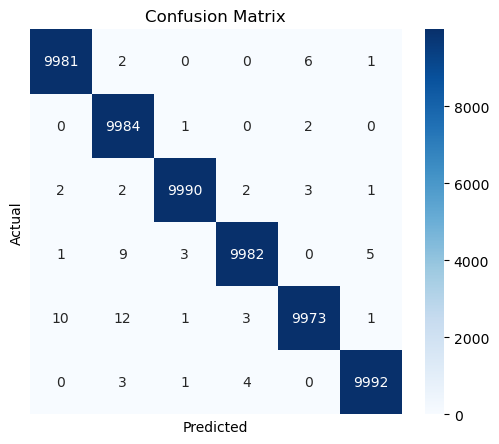

,params,rank_test_score,mean_test_score,std_test_score
model,,,,
unified_0.001,"{'B_compute': 'unified', 'lambd': 0.001}",1,1.000000,0.000000
unified_0.005,"{'B_compute': 'unified', 'lambd': 0.005}",1,1.000000,0.000000
unified_0.01,"{'B_compute': 'unified', 'lambd': 0.01}",1,1.000000,0.000000
unified_0.05,"{'B_compute': 'unified', 'lambd': 0.05}",1,1.000000,0.000000
unified_0.1,"{'B_compute': 'unified', 'lambd': 0.1}",1,1.000000,0.000000
unified_0.5,"{'B_compute': 'unified', 'lambd': 0.5}",1,1.000000,0.000000
not_unified_0.001,"{'B_compute': 'not_unified', 'lambd': 0.001}",1,1.000000,0.000000
not_unified_0.005,"{'B_compute': 'not_unified', 'lambd': 0.005}",1,1.000000,0.000000
not_unified_0.01,"{'B_compute': 'not_unified', 'lambd': 0.01}",1,1.000000,0.000000


In [39]:
param_grid = {
    "lambd": [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1],
    "B_compute": ["unified", "not_unified"]
}

II = IdentificadorIdiomas(method="linear_discounting")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=83)

gs_ld = GridSearchCV(
    estimator=II,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs_ld.fit(X_training, y_training)

y_pred = gs_ld.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=II.labels, yticklabels=II.labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_ld.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]

### Absolute discounting
De la formula de smoothing de absolute discounting, per trigrams:

$$ P(w_1 w_2 w_3) = \left\{ \begin{array}{l}  (1 - \delta)\frac{C(w_1 w_2 w_3) - \delta}{N} \\ \frac{(B - N_0) \delta / N_0}{N} \end{array} \begin{array}{l} if \ C(w_1 w_2 w_3) > 0 \\ otherwise \end{array}\right. $$

A més del que hem vist a `lidstone` i `linear_discounting` necessitem $\delta$ de la cual que no sabem el seu millor valor.  
Per tant, per saber si pel mètode de smoothing lidstone es millor utilitzar una $B$ diferent per cada llengüatge o si es millor unificar-les i, a més, per saber quina $\delta$ es millor, farem un crossvalidation per trobar el millor model.

In [40]:
param_grid = {
    "lambd": [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1],
    "B_compute": ["unified", "not_unified"]
}

II = IdentificadorIdiomas(method="absolute_discounting")

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=65)

gs_ad = GridSearchCV(
    estimator=II,
    param_grid=param_grid,
    scoring='accuracy',
    cv=cv,
    n_jobs=-1
)

gs_ad.fit(X_training, y_training)

y_pred = gs_ad.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy}")

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=II.labels, yticklabels=II.labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

results_df = pd.DataFrame(gs_ad.cv_results_)
results_df = results_df.sort_values(by=["rank_test_score"])
results_df = results_df.set_index(results_df["params"].apply(lambda x: "_".join(str(val) for val in x.values()))).rename_axis("model")
results_df[["params", "rank_test_score", "mean_test_score", "std_test_score"]]


Caching the list of root modules, please wait!
(This will only be done once - type '%rehashx' to reset cache!)



KeyboardInterrupt: 